# Car Price Analysis with PCA and PLS Regression

This notebook performs a comprehensive analysis of car prices using Partial Least Squares (PLS) regression and feature engineering. The analysis focuses on ludospace vehicle models and explores different approaches to price prediction.

In [1382]:
from datetime import datetime
print(f"Last execution date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Last execution date: 2025-09-04 20:11:50


## Overview
- Load and explore the dataset of ludospace vehicles
- Apply feature engineering and preprocessing
- Compare linear vs log-transformed price models
- Evaluate model performance using MAPE, MAE, and R² metrics
- Find the most interesting car deals based on predicted vs actual prices

## 1. Setup and Imports

First, we import all necessary libraries and set up the environment:
- Database connection utilities for loading car data
- Scikit-learn modules for machine learning (PLS, preprocessing, metrics)
- Data manipulation and visualization libraries

In [1383]:
import sys
import os

# Add src to path
sys.path.append(os.path.abspath('../src'))

# Database connection
from data.database import get_car_items

from IPython.core.display import HTML

from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, is_regressor
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error, mean_absolute_error
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import TransformedTargetRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

import numpy as np
import pandas as pd

import itables

pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 80)

pub_date_formatter = itables.JavascriptFunction(
    """
    function (td, cellData, rowData, row, col) {
        if (cellData == 0) {
            $(td).html("Today").css('color', 'red').css('font-weight', 'bold');
        } else if (cellData == 1) {
            $(td).html("Yesterday").css('color', 'orange').css('font-weight', 'bold');
        } else if (cellData <= 7) {
            $(td).html(cellData + " d").css('color', 'orange').css('font-weight', 'bold');
        } else {
            $(td).html(cellData + " d");
        }
    }
    """
)
    
distance_formatter = itables.JavascriptFunction(
    """
    function (td, cellData, rowData, row, col) {
        if (cellData > 500) {
            $(td).html(cellData + " km").css('color', 'red')
        } else if (cellData > 300) {
            $(td).html(cellData + " km").css('color', 'orange')
        } else if (cellData > 200) {
            $(td).html(cellData + " km").css('color', '#b8860b')
        } else {
            $(td).html(cellData + " km").css('color', 'green')
        }
    }
    """
)

price_formatter = itables.JavascriptFunction(
    """
    function (td, cellData, rowData, row, col) {
        $(td).html(cellData + " €");
    }
    """
)

percent_formatter = itables.JavascriptFunction(
    """
    function (td, cellData, rowData, row, col) {
        $(td).html(cellData + ' %');
    }
    """
)

seats_formatter = itables.JavascriptFunction(
    """
    function (td, cellData, rowData, row, col) {
        if (cellData == 999999) {
            $(td).html("7+");
        } else if (cellData == 'None') {
            $(td).html("-");
        } else {
            $(td).html(cellData);
        }
    }
    """
)

column_alias = {
    "predicted_price": "Pred. Price",
    "relative_difference": "Rel. Diff.",
    "first_publication_date": "Pub. Date",
    "price": "Price",
    "seats": "Seats",
    "distance": "Distance",
    "model": "Model",
    "mileage": "Mileage",
    "issuance_date": "Iss. Date",
    "subject": "Subject",
    "cluster": "Cluster",
    "rank_cluster": "Rank in Cluster",
    "rank": "Rank"
}

formatters = {
    column_alias["price"]: lambda x: x.astype(int),
    column_alias["predicted_price"]: lambda x: x.astype(int),
    column_alias["relative_difference"]: lambda x: (x*100).round(0).astype(int),
    column_alias["mileage"]: lambda x: x.astype(int),
    # apply function to each element of the serie
    column_alias["first_publication_date"]: lambda x: (pd.to_datetime('today') - pd.to_datetime(x)).dt.days,
    column_alias["seats"]: lambda x: x.fillna('0').astype(int),
    column_alias["distance"]: lambda x: x.astype(int),
}


def show_cars(df, filters = None, order = None):
    interesting_cars = df.copy()
    filters = filters or []
    order = order or []
    print("order:", order)

    # create an html link for the subject (url)
    interesting_cars['subject'] = interesting_cars.apply(
        lambda row: f"<a target='_blank' href='{row['url']}'>{row['subject']}</a>", axis=1
    )
    # select only the following columns if they are present in the dataframe
    columns = ['model', 'mileage', 'issuance_date', 'price', 'subject', 'seats', 'first_publication_date', 'distance',  'relative_difference', 'predicted_price', 'cluster', 'rank_cluster', 'rank']
    columns = [col for col in columns if col in interesting_cars.columns]
    rename = {col: column_alias[col] for col in columns if col in column_alias}
    format = {col: formatters[col] for col in rename.values() if col in formatters}
    interesting_cars = interesting_cars.rename(columns=rename)
    # keep only relevant columns
    interesting_cars = interesting_cars[rename.values()]

    for col, fmt in format.items():
        if col in interesting_cars.columns:
           interesting_cars[col] = fmt(interesting_cars[col])

    def column_id(name):
        return interesting_cars.columns.get_loc(name)+1


    itables.show(interesting_cars, pageLength=25, allow_html=True,
         columnDefs=[
            {
                "targets": [column_id("Price")],
                "createdCell": price_formatter,
            } if "Price" in interesting_cars.columns else {},
            {
                "targets": [column_id("Pred. Price")],
                "createdCell": price_formatter,
            } if "Pred. Price" in interesting_cars.columns else {},
            {
                "targets": [column_id("Rel. Diff.")],
                "createdCell": percent_formatter,
            } if "Rel. Diff." in interesting_cars.columns else {},
            {
                "targets": [column_id("Distance")],
                "createdCell": distance_formatter,
            } if "Distance" in interesting_cars.columns else {},
            {
                "targets": [column_id("Pub. Date")],
                "createdCell": pub_date_formatter,
            } if "Pub. Date" in interesting_cars.columns else {},
            {
                "targets": [column_id("Seats")],
                "createdCell": seats_formatter,
            } if "Seats" in interesting_cars.columns else {},
        ],
        layout={"top1": "searchBuilder"},
        searchBuilder={
            "preDefined": {
                "criteria": [
                    {"data": column, "condition": condition, "value": [value]} for (column, condition, value) in filters
                ]
            }
        },
        order=[[column_id(col), dir] for (col, dir) in order]
    )


class FlooredRegressor(RegressorMixin):
    def __init__(self, regressor, min_value=0):
        self.regressor = regressor
        self.min_value = min_value
    
    def fit(self, X, y):
        self.regressor.fit(X, y)
        return self
    
    def predict(self, X):
        predictions = self.regressor.predict(X)
        return np.maximum(predictions, self.min_value)

    # Add these methods for sklearn compatibility
    def get_params(self, deep=True):
        return {'regressor': self.regressor, 'min_value': self.min_value}
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


## 2. Data Loading and Exploration

Load the ludospace vehicle dataset and perform initial exploration:
- Load specific ludospace models (van-like vehicles with good space utilization)
- Clean the dataset by removing records with missing essential data
- Examine the distribution of models and price ranges

TOP MOST FREQUENT MODELS
                         price              
                         count    min    max
model                                       
RENAULT_Kangoo              54   1490  39790
CITROEN_Berlingo            47   7490  37900
MERCEDES-BENZ_EQT           34  20990  49559
PEUGEOT_Rifter              29  17390  36050
OPEL_Combo                   8  19290  29900
OPEL_Combo Life              5  19990  27489
TOYOTA_PROACE CITY Verso     5  23999  30000


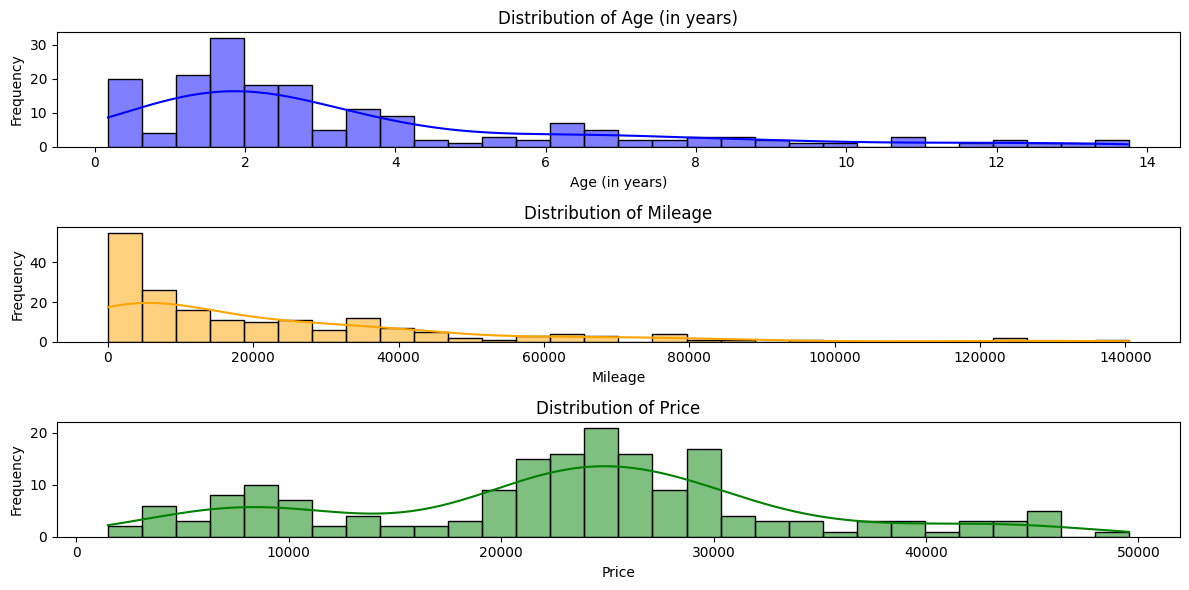

In [1384]:
LUDOSPACE = ['RENAULT_Kangoo', 'TOYOTA_PROACE CITY Verso', 'PEUGEOT_Rifter', 'CITROEN_Berlingo', 'OPEL_Combo', 'OPEL_Combo Life', 'FIAT_Doblo', 'MERCEDES-BENZ_EQT']

full_raw_dataset = get_car_items(models=LUDOSPACE)
full_raw_dataset = full_raw_dataset.dropna(subset=['price', 'mileage', 'age_in_days'])

# remove cars with only 2, 3 or 4 seats
full_raw_dataset = full_raw_dataset[~full_raw_dataset['seats'].astype(str).isin(['2', '3', '4'])]

IGNORE_URL = [
    'https://www.leboncoin.fr/ad/utilitaires/2881783262',
    'https://www.leboncoin.fr/ad/utilitaires/3037379996',
    'https://www.leboncoin.fr/ad/utilitaires/3032920162',
    'https://www.leboncoin.fr/ad/utilitaires/2986559704',
    'https://www.leboncoin.fr/ad/utilitaires/3029388180',
    'https://www.leboncoin.fr/ad/utilitaires/3033045893',
    'https://www.leboncoin.fr/ad/utilitaires/3041724626',
    'https://www.leboncoin.fr/ad/utilitaires/2959800932',
    'https://www.leboncoin.fr/ad/utilitaires/3046683749',
    'https://www.leboncoin.fr/ad/utilitaires/3041723386',
    'https://www.leboncoin.fr/ad/utilitaires/2879353914',
    'https://www.leboncoin.fr/ad/utilitaires/3042301395',
    'https://www.leboncoin.fr/ad/utilitaires/3012155472',
    'https://www.leboncoin.fr/ad/utilitaires/2422504570'
]
full_raw_dataset = full_raw_dataset[~full_raw_dataset['url'].isin(IGNORE_URL)]



# remove those very far
MAX_DISTANCE = 1500
full_raw_dataset = full_raw_dataset[full_raw_dataset['distance'] < MAX_DISTANCE]

# remove those with very small battery
IGNORE_HORSE_POWER = [47, 67]
full_raw_dataset = full_raw_dataset[~full_raw_dataset['horse_power_din'].isin(IGNORE_HORSE_POWER)]

# print the top 10 most frequent models
print("TOP MOST FREQUENT MODELS")
print("="*80)
print(full_raw_dataset.groupby('model').agg({'price': ['count', 'min', 'max']}).sort_values(by=('price', 'count'), ascending=False))

# plot with 3 histograms subplot for age, mileage and price with 3 different colors
fig, axs = plt.subplots(3, 1, figsize=(12, 6))
sns.histplot(full_raw_dataset['age_in_days']/365.25, bins=30, ax=axs[0], kde=True, color='blue')
axs[0].set_title('Distribution of Age (in years)')
axs[0].set_xlabel('Age (in years)')
axs[0].set_ylabel('Frequency')

sns.histplot(full_raw_dataset['mileage'], bins=30, ax=axs[1], kde=True, color='orange')
axs[1].set_title('Distribution of Mileage')
axs[1].set_xlabel('Mileage')
axs[1].set_ylabel('Frequency')

sns.histplot(full_raw_dataset['price'], bins=30, ax=axs[2], kde=True, color='green')
axs[2].set_title('Distribution of Price')
axs[2].set_xlabel('Price')
axs[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [1385]:
SELECTED_MODEL = None #'RENAULT_Kangoo' # 'HYUNDAI_Kona'

if SELECTED_MODEL is None:
    single_model_dataset = full_raw_dataset
    print(f"Analyzing all models dataset: {single_model_dataset.shape[0]} samples")
else:
    single_model_dataset = full_raw_dataset[(full_raw_dataset['model'] == SELECTED_MODEL) & (full_raw_dataset['issuance_date'] < '2022-01-01')]
    print(f"Analyzing {SELECTED_MODEL} dataset: {single_model_dataset.shape[0]} samples")

print("TOP MOST RECENTLY PUBLISHED CARS")
print("="*80)
recent = single_model_dataset.sort_values(by='first_publication_date', ascending=False)
show_cars(recent, filters=[("Pub. Date", "<", '7')], order=[('Pub. Date', 'asc')])

Analyzing all models dataset: 182 samples
TOP MOST RECENTLY PUBLISHED CARS
order: [('Pub. Date', 'asc')]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


## 3. Clustering

### 3.1 by Age, Mileage using K-means

This section implements a clustering using k means

Cluster Analysis Summary:
         mileage_mean  mileage_std  mileage_count  age_years_mean  price_mean  price_std  price_min  price_max
cluster                                                                                                       
0             1096.31      2014.34             35            0.66    32965.63    6904.28      24750      49559
1             4393.74      3454.84             46            1.89    29498.98    6798.23      21990      46200
2            15462.68      5394.04             25            2.50    24783.88    5053.62      19290      44200
3            34199.55      6418.49             29            3.14    21560.31    3915.29       9990      28290
4            67622.29     10529.00              7            3.88    17585.43    2861.62      12000      19540
5            18152.44      7405.10             18            6.80     9831.89    2538.48       6099      14990
6            62685.33     14045.65              9            7.80     7456.67    2232.

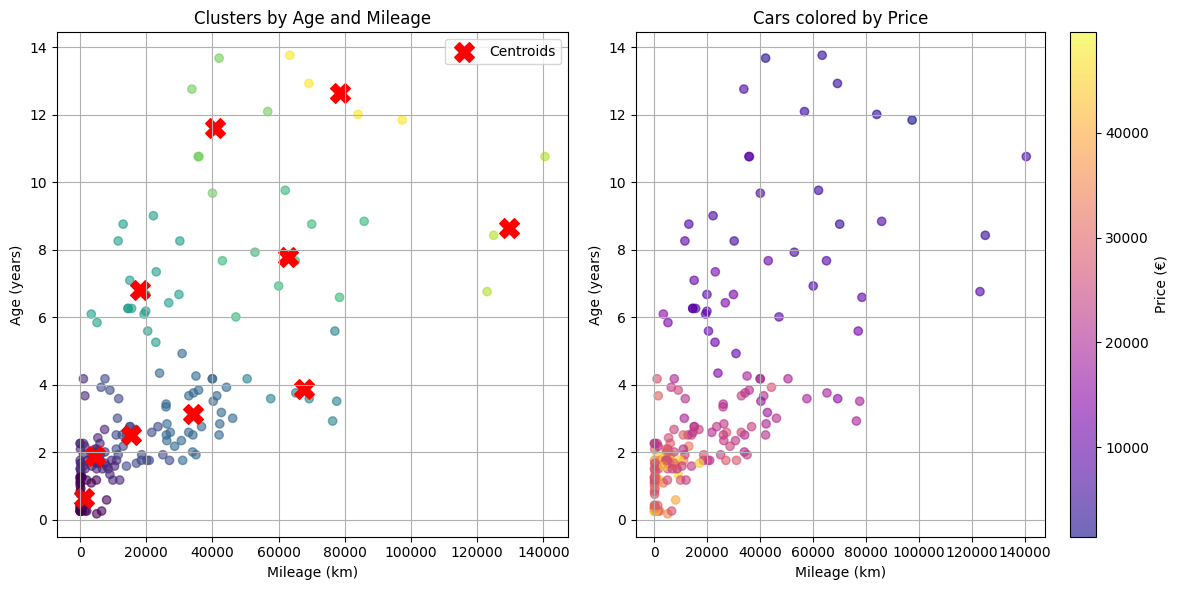

In [1386]:
K = 10

# Prepare clustering features
clustering_features = single_model_dataset[['mileage', 'age_in_days']].copy()

# Convert age to years for better interpretability
clustering_features['age_in_years'] = clustering_features['age_in_days'] / 365.25
clustering_features = clustering_features[['mileage', 'age_in_years']]

# Create clustering pipeline with scaler and KMeans
optimal_k = K
clustering_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=optimal_k, random_state=42, n_init=10))
])

# Fit the pipeline and get cluster labels
cluster_labels = clustering_pipeline.fit_predict(clustering_features)

# Add cluster labels to dataset: rank the cluster id from 0 to optimal_k-1, starting from the lowest mean price
clustering_results = single_model_dataset.copy()
clustering_results['cluster'] = cluster_labels
cluster_price_means = clustering_results.groupby('cluster')['price'].mean().sort_values(ascending=False)
ranked_clusters = cluster_price_means.index.tolist()
cluster_id_map = {old: new for new, old in enumerate(ranked_clusters)}
cluster_labels = [cluster_id_map[c] for c in cluster_labels]
single_model_dataset['cluster'] = cluster_labels
clustering_results = single_model_dataset.copy()

# Analyze clusters
print("Cluster Analysis Summary:")
print("=" * 50)
cluster_summary = clustering_results.groupby('cluster').agg({
    'mileage': ['mean', 'std', 'count'],
    'age_in_days': lambda x: (x / 365.25).mean(),  # Convert to years
    'price': ['mean', 'std', 'min', 'max']
}).round(2)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary.rename(columns={'age_in_days_<lambda>': 'age_years_mean'}, inplace=True)

print(cluster_summary)

# Get cluster centers from the pipeline
# First transform the data with the scaler, then get centers from KMeans
scaler = clustering_pipeline.named_steps['scaler']
kmeans = clustering_pipeline.named_steps['kmeans']

# Get scaled centers and transform back to original space
cluster_centers_scaled = kmeans.cluster_centers_
# reorder cluster_centers_scaled to match the re-ordered cluster id
cluster_centers_scaled = cluster_centers_scaled[ranked_clusters]
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

print("\nCluster Centers:")
print("=" * 30)
for i, center in enumerate(cluster_centers_original):
    print(f"Cluster {i}: Mileage={center[0]:.0f} km, Age={center[1]:.1f} years")

# Create a more detailed visualization with price information
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Clusters colored by cluster
scatter1 = axes[0].scatter(clustering_features['mileage'], clustering_features['age_in_years'], 
                          c=cluster_labels, cmap='viridis', alpha=0.6)
axes[0].scatter(cluster_centers_original[:, 0], cluster_centers_original[:, 1], 
               c='red', marker='X', s=200, label='Centroids')
axes[0].set_xlabel('Mileage (km)')
axes[0].set_ylabel('Age (years)')
axes[0].set_title('Clusters by Age and Mileage')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Same points colored by price
scatter2 = axes[1].scatter(clustering_features['mileage'], clustering_features['age_in_years'], 
                          c=clustering_results['price'], cmap='plasma', alpha=0.6)
axes[1].set_xlabel('Mileage (km)')
axes[1].set_ylabel('Age (years)')
axes[1].set_title('Cars colored by Price')
plt.colorbar(scatter2, ax=axes[1], label='Price (€)')
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 4. Simplified Models for Interpretability

After the complex analysis, we create simplified models that are easier to interpret and apply in practice.

### 4.1 Simple Linear Model

A basic linear model using only mileage and age as features:
```
price = base_price - a × mileage_in_1000km - b × age_in_years
```

This provides a straightforward formula for quick price estimation.

In [1387]:
training_set = single_model_dataset.copy()

# remove unrealistic prices
MAX_PRICE = 35000
training_set = training_set[training_set['price'] < MAX_PRICE]
MIN_PRICE = 3000
training_set = training_set[training_set['price'] > MIN_PRICE]

# remove those with an unknown number of seats
training_set = training_set[training_set['seats'].notna()]

# Prepare features and targets
X_simple_features = training_set[['mileage', 'age_in_days']].copy()
y_price = training_set['price'].copy()

# create test and train sets
X_train, X_test, y_train, y_test = train_test_split(
    X_simple_features, y_price, 
    train_size=0.6, # given that we only have 3 params to evaluate, we don't need a large training set
    random_state=42,
    stratify=training_set['cluster']
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 78 samples
Test set size: 52 samples


In [1388]:
# use a simple model for the predictions

simple_pipeline = FlooredRegressor(
    regressor=Pipeline([
        ('scaler', RobustScaler()),
        ('pls', PLSRegression()),
    ]), min_value=0
)
simple_pipeline.fit(X_train, y_train)
test_pred = simple_pipeline.predict(X_test)

# print score R2, MAE and MAPE
print("Simple model R^2 score:", r2_score(y_test, test_pred))
print("Simple model MAE:", mean_absolute_error(y_test, test_pred))
print("Simple model MAPE:", mean_absolute_percentage_error(y_test, test_pred))

# print a few prediction examples
sample_cars = pd.DataFrame({
    'mileage': [0, 1000, 0],
    'age_in_days': [0, 0, 365]
})
sample_cars_prices = simple_pipeline.predict(sample_cars)
print("Sample car prices:", sample_cars_prices)

# print the formula as price = base_price - a * mileage - b * age_in_days

base_price = sample_cars_prices[0]
a = sample_cars_prices[0] - sample_cars_prices[1]  # price for 1000 mileage
b = sample_cars_prices[0] - sample_cars_prices[2]  # price for 1 year old car
print(f"Simple model formula: price = {base_price:.0f} - {a:.0f} * mileage_kkms - {b:.0f} years")

# check formula for the whole dataset
# function_pred = base_price -a * (X_simple_features['mileage'] / 1000) - b * (X_simple_features['age_in_days'] / 365.25)
# print("Formula is close to the predictions with a max error:", np.max(function_pred - y_simple_pred))

Simple model R^2 score: 0.7672102775842964
Simple model MAE: 2790.8345680688317
Simple model MAPE: 0.16852457086753297
Sample car prices: [29918.59852206 29868.95591704 27880.75998496]
Simple model formula: price = 29919 - 50 * mileage_kkms - 2038 years


### 4.2 Simple Logarithmic Model

A logarithmic model that captures exponential depreciation patterns:
```
price = base_price × exp(-a × mileage_in_1000km) × exp(-b × age_in_years) - 1
```

This model reflects the reality that cars lose value at a decreasing rate over time, showing percentage-based depreciation rather than linear.

In [1389]:
# use a simple model for the predictions
simple_log_pipeline = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', RobustScaler()),
        ('pls', PLSRegression())
    ]),
    func=np.log1p,  # Transform target to log scale
    inverse_func=np.expm1  # Transform predictions back to original scale
)

simple_log_pipeline.fit(X_train, y_train)
test_pred = simple_log_pipeline.predict(X_test)

# print score R2, MAE and MAPE
print("Simple model R^2 score:", r2_score(y_test, test_pred))
print("Simple model MAE:", mean_absolute_error(y_test, test_pred))
print("Simple model MAPE:", mean_absolute_percentage_error(y_test, test_pred))

# print a few prediction examples
sample_cars = pd.DataFrame({
    'mileage': [0, 1000, 0],
    'age_in_days': [0, 0, 365]
})
sample_cars_prices = simple_log_pipeline.predict(sample_cars)
print("Sample car prices:", sample_cars_prices)

# np.log1p(price) = C - a * mileage -b * years
# price = np.expm1(C - a * mileage -b * years)
# price = np.exp(C - a * mileage -b * years) - 1
# price = np.exp(C) * np.exp(- a * mileage) * np.exp(- b * years) - 1
# price + 1 = np.exp(C) * np.exp(- a * mileage) * np.exp(- b * years)
# np.log1p(price0) = C


# print the formula as price = base_price * np.expm1(- a * mileage) * np.expm1(- b * years)


c = np.log1p(sample_cars_prices[0])
a = np.log1p(sample_cars_prices[0]) - np.log1p(sample_cars_prices[1])  # price for 1000 mileage
b = np.log1p(sample_cars_prices[0]) - np.log1p(sample_cars_prices[2])  # price for 1 year old car
base_price = np.exp(c)
print(f"Simple model formula: price = {base_price:.0f} * np.exp(- {a:.5f} * mileage_kkms) * np.exp(- {b:.5f} * years) - 1")
print(f" i.e. Price is reduced by {np.expm1(-a) * 100:.1f}% for each 1000 km of mileage and by {np.expm1(-b) * 100:.1f}% for each year of age")

function_pred = (base_price) * np.exp(- a * (X_test['mileage'] / 1000)) * np.exp(- b * (X_test['age_in_days'] / 365.25)) - 1
print("Formula is close to the predictions with a max error:", np.max(np.abs(function_pred - test_pred)))

# A**x = exp(x ln(A)), ln(A) = - a
# price = base_price * np.expm1(- a * mileage) * np.expm1(- b * years)
# price = base_price * (exp(- a * mileage) - 1) * (exp(- b * years) - 1)


# check formula for the whole dataset
# base_price = sample_cars_prices[0]
# print(f" i.e. Price is reduced by {a * 100:.1f}% for each 1000 km of mileage and by {b * 100:.1f}% for each year of age")
# function_pred = (base_price + 1) * np.pow(np.exp(-a), (X_simple_features['mileage'] / 1000)) * np.pow(np.exp(-b), (X_simple_features['age_in_days'] / 365.25)) - 1
# print("Formula is close to the predictions with a max error:", np.max(function_pred - y_simple_log_pred))

Simple model R^2 score: 0.7846564465182932
Simple model MAE: 2651.312847142268
Simple model MAPE: 0.13357069878279268
Sample car prices: [34439.71961753 34323.22859545 30016.51583229]
Simple model formula: price = 34441 * np.exp(- 0.00339 * mileage_kkms) * np.exp(- 0.13746 * years) - 1
 i.e. Price is reduced by -0.3% for each 1000 km of mileage and by -12.8% for each year of age
Formula is close to the predictions with a max error: 8.451240693295404


### 4.3 Ensemble Model (Voting Regressor)

Combine the linear and logarithmic models using a weighted voting approach. We use grid search to find the optimal weights that minimize MAPE across both models.

In [1390]:
mixed_model = {
    'pipe': VotingRegressor([
        ('linear', simple_pipeline),
        ('log', simple_log_pipeline)
    ]),
    'param_grid': {
        'weights': [[a, 1-a] for a in np.linspace(0, 1, 11)]
    }
}

grid_search = GridSearchCV(
    estimator=mixed_model['pipe'],
    param_grid=mixed_model['param_grid'],
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    verbose=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)
test_pred = best_model.predict(X_test)
# print score R2, MAE and MAPE
print("Simple model R^2 score:", r2_score(y_test, test_pred))
print("Simple model MAE:", mean_absolute_error(y_test, test_pred))
print("Simple model MAPE:", mean_absolute_percentage_error(y_test, test_pred))

# print a few prediction examples
sample_cars = pd.DataFrame({
    'mileage': [0, 1000, 0],
    'age_in_days': [0, 0, 365]
})
sample_cars_prices = best_model.predict(sample_cars)
print("Sample car prices:", sample_cars_prices)

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Best parameters found:  {'weights': [np.float64(0.0), np.float64(1.0)]}
Simple model R^2 score: 0.7846564465182932
Simple model MAE: 2651.312847142268
Simple model MAPE: 0.13357069878279268
Sample car prices: [34439.71961753 34323.22859545 30016.51583229]


### 4.4 Reference XGBoost model

In [1391]:
# use X_train, Y_train to train an XGBoost model
import xgboost as xgb

# xgb_model = Pipeline([
#     ("scaler", RobustScaler()),
#     ("model", xgb.XGBRegressor(objective='reg:squarederror'))
# ])

# The linear regression based on log transformation provided a better result than the linear regression,
# Reuse the same here
xgb_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', RobustScaler()),
        ('xgb', xgb.XGBRegressor(objective='reg:squarederror'))
    ]),
    func=np.log1p,  # Transform target to log scale
    inverse_func=np.expm1  # Transform predictions back to original scale
)
xgb_model.fit(X_train, y_train)

test_pred = xgb_model.predict(X_test)
print("Simple model R^2 score:", r2_score(y_test, test_pred))
print("Simple model MAE:", mean_absolute_error(y_test, test_pred))
print("Simple model MAPE:", mean_absolute_percentage_error(y_test, test_pred))

# print a few prediction examples
sample_cars = pd.DataFrame({
    'mileage': [0, 1000, 0],
    'age_in_days': [0, 0, 365]
})
sample_cars_prices = xgb_model.predict(sample_cars)
print("Sample car prices:", sample_cars_prices)

Simple model R^2 score: 0.7561322450637817
Simple model MAE: 2929.67236328125
Simple model MAPE: 0.1376190185546875
Sample car prices: [28200.82  27570.867 26523.785]


## 5. Model Performance Visualization

Compare the performance of all three simplified models:
- Simple linear model
- Simple logarithmic model  
- Best ensemble model

The scatter plot shows predicted vs actual prices to visualize model accuracy.

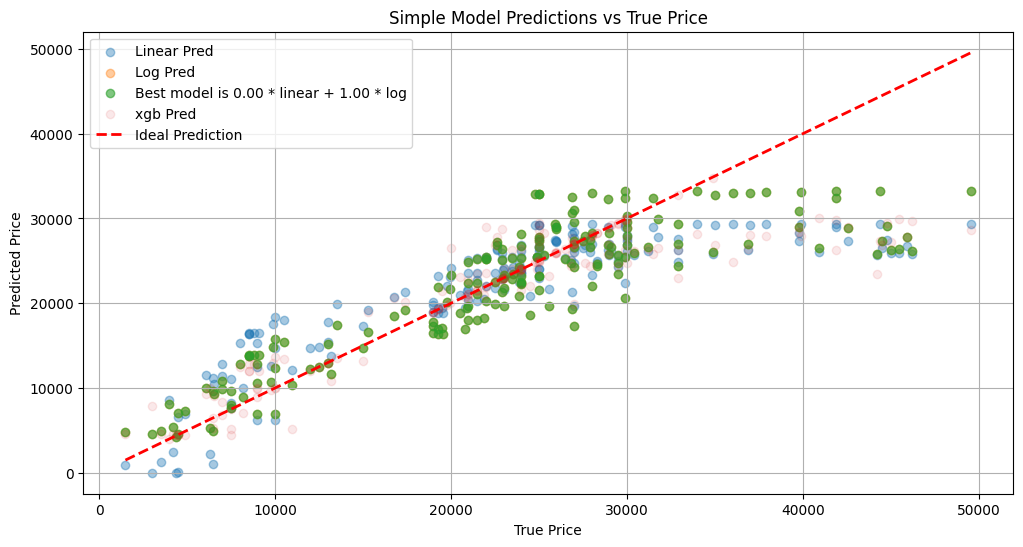

In [1392]:
# draw a plot showing simple_pred and simple_log_pred vs price
import matplotlib.pyplot as plt

X_feature = single_model_dataset[['mileage', 'age_in_days']]
best_model_predict = best_model.predict(X_feature)
y_simple_log_pred = simple_log_pipeline.predict(X_feature)
y_simple_pred = simple_pipeline.predict(X_feature)
xgb_pred = xgb_model.predict(X_feature)
y_price = single_model_dataset['price']

# best_model is a weighted average of linear and log models
linear_weight, log_weight = best_model.weights
best_model_desc = f"Best model is {linear_weight:.2f} * linear + {log_weight:.2f} * log"

plt.figure(figsize=(12, 6))
plt.scatter(y_price, y_simple_pred, label='Linear Pred', alpha=0.4)
plt.scatter(y_price, y_simple_log_pred, label='Log Pred', alpha=0.4)
plt.scatter(y_price, best_model_predict, label=best_model_desc, alpha=0.6)
plt.scatter(y_price, xgb_pred, label='xgb Pred', alpha=0.1)
plt.plot([y_price.min(), y_price.max()], [y_price.min(), y_price.max()], 'r--', lw=2, label='Ideal Prediction')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('Simple Model Predictions vs True Price')
plt.legend()
plt.grid()
plt.show()

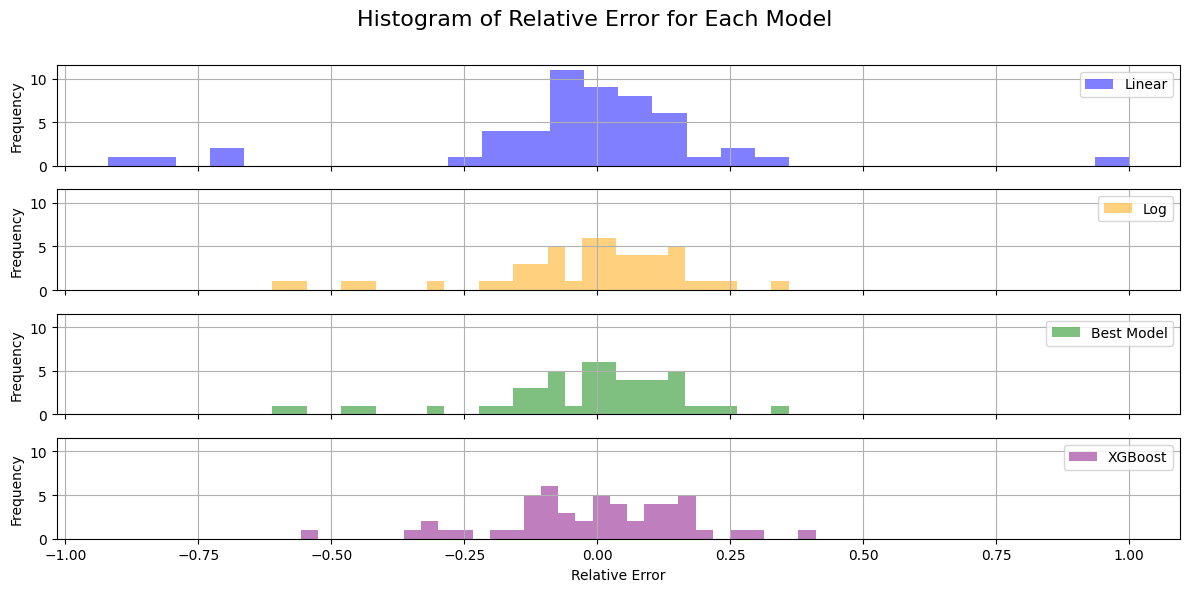

In [1393]:
# for each model plot an histogram of the relative error
def plot_relative_error_histogram(X_test, y_test, model, model_name, ax):
    y_pred = model.predict(X_test)
    relative_error = (y_test - y_pred) / y_test
    ax.hist(relative_error, bins=30, alpha=0.5, label=model_name)
    

fig, axs = plt.subplots(4, 1, figsize=(12, 6), sharex=True, sharey=True)

plot_relative_error_histogram(X_test, y_test, simple_pipeline, 'Linear', axs[0])
plot_relative_error_histogram(X_test, y_test, simple_log_pipeline, 'Log', axs[1])
plot_relative_error_histogram(X_test, y_test, best_model, 'Best Model', axs[2])
plot_relative_error_histogram(X_test, y_test, xgb_model, 'XGBoost', axs[3])

colors = ['blue', 'orange', 'green', 'purple']
for ax, color in zip(axs, colors):
    for patch in ax.patches:
        patch.set_facecolor(color)
    ax.legend()
    ax.set_ylabel('Frequency')
    ax.grid(True)

axs[-1].set_xlabel('Relative Error')
fig.suptitle('Histogram of Relative Error for Each Model', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 6. Finding the Best Deals

Identify the most interesting cars in the dataset by comparing predicted prices with actual listing prices. Cars with the highest positive difference (predicted > actual) represent the best potential deals.

### Filtering Criteria:
- Maximum price threshold (€35,000)
- Exclude specific engine configurations (67 HP models - small battery EVs)
- Calculate relative price difference as percentage of predicted value

In [1394]:
# display the most interesting cars from the dataset; i.e., order by (predicted_price - price)/predicted_price desc
enriched_dataset = single_model_dataset.copy()

enriched_dataset['predicted_price'] = best_model_predict
enriched_dataset['predicted_price_log'] = y_simple_log_pred
enriched_dataset['price_difference'] = enriched_dataset['predicted_price'] - enriched_dataset['price']
enriched_dataset['relative_difference'] = (enriched_dataset['price_difference'] / enriched_dataset['predicted_price'])
enriched_dataset = enriched_dataset.sort_values(by='relative_difference', ascending=False)
enriched_dataset['#'] = range(1, len(enriched_dataset) + 1)
enriched_dataset = enriched_dataset.set_index('#')

# rank sorted by price
enriched_dataset['rank_in_cluster'] = enriched_dataset.groupby('cluster')['price'].rank(method='min')
# count in cluster
enriched_dataset['count_in_cluster'] = enriched_dataset.groupby('cluster')['price'].transform('count')
enriched_dataset['rank_cluster'] = ((100*enriched_dataset['rank_in_cluster'] / enriched_dataset['count_in_cluster']).astype(int)).apply(lambda x: f"{x} %")

# compute the rank of the car, i.e. if we filter only on the car having less miles and less age, how many are less expensive
ranks = [
    np.sum((single_model_dataset['mileage'] <= row['mileage']) & (single_model_dataset['age_in_days'] <= row['age_in_days']) & (single_model_dataset['price'] <= row['price']))
    for _, row in enriched_dataset.iterrows()
]
enriched_dataset['rank'] = ranks

# update the index of each row so that it is now its rank in the dataset order by relative_difference
enriched_dataset = enriched_dataset.sort_values(by='relative_difference', ascending=False)



# filter the dataset for cars below the max price
interesting_cars = enriched_dataset.copy()


print("MOST INTERESTING CARS (by relative price difference)")
print(f"{'='*80}")

# render as html,
MAX_DISTANCE = 500
MAX_PRICE = 28000
DEFAULT_FILTERS = [("Distance", "<", MAX_DISTANCE), ("Price", "<", MAX_PRICE), ("Seats", ">=", 5)]
DEFAULT_ORDER = [('Rel. Diff.', 'desc')]
show_cars(interesting_cars,
          filters=DEFAULT_FILTERS,
          order=DEFAULT_ORDER)

MOST INTERESTING CARS (by relative price difference)
order: [('Rel. Diff.', 'desc')]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [1395]:
CARS_PER_CLUSTER = 10
print(f"\n{CARS_PER_CLUSTER} LESS EXPENSIVE CARS (by cluster)")
print("=" * 50)
for cluster_id, center in enumerate(cluster_centers_original):
    print(f"Cluster {cluster_id}: Mileage={center[0]:.0f} km, Age={center[1]:.1f} years")
    cluster_list = [i for i, c in enumerate(cluster_centers_original) if c[0] <= center[0] and c[1] <= center[1]]
    print(f"including all clusters having a center with less mileage and less age: {cluster_list}")
    cluster_cars = interesting_cars[interesting_cars['cluster'].isin(cluster_list)]
    if not cluster_cars.empty:
        less_expensive_cars = cluster_cars.nsmallest(CARS_PER_CLUSTER, 'price')
        show_cars(less_expensive_cars, filters=[("Cluster", "=", cluster_id), *DEFAULT_FILTERS], order=[("Price", "asc")])
    else:
        print(f"Cluster {cluster_id}: No cars found.")


10 LESS EXPENSIVE CARS (by cluster)
Cluster 0: Mileage=1096 km, Age=0.7 years
including all clusters having a center with less mileage and less age: [0]
order: [('Price', 'asc')]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Cluster 1: Mileage=4394 km, Age=1.9 years
including all clusters having a center with less mileage and less age: [0, 1]
order: [('Price', 'asc')]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Cluster 2: Mileage=15463 km, Age=2.5 years
including all clusters having a center with less mileage and less age: [0, 1, 2]
order: [('Price', 'asc')]


...

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Cluster 8: Mileage=129500 km, Age=8.6 years
including all clusters having a center with less mileage and less age: [0, 1, 2, 3, 4, 5, 6, 8]
order: [('Price', 'asc')]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Cluster 9: Mileage=78473 km, Age=12.6 years
including all clusters having a center with less mileage and less age: [0, 1, 2, 3, 4, 5, 6, 7, 9]
order: [('Price', 'asc')]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


### 6.1 Specialized Vehicle Search

Filter for specific vehicle variants (XL, Grand, Long) which typically offer more space and utility, making them particularly interesting for certain use cases.

In [1396]:
# filter only the ones with subject containing XL, Grand, or Long (case insensitive)
show_cars(interesting_cars[interesting_cars['subject'].str.contains('XL|Grand|Long|Maxi', case=False, na=False)], filters=DEFAULT_FILTERS, order=DEFAULT_ORDER)

order: [('Rel. Diff.', 'desc')]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
